In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Regression diagnostics
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson

# Time series tools
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Models
from statsmodels.regression.linear_model import OLS, WLS

import warnings
warnings.filterwarnings('ignore')

=== 1. EDA: scatter, outliers, histogram, KDE ===


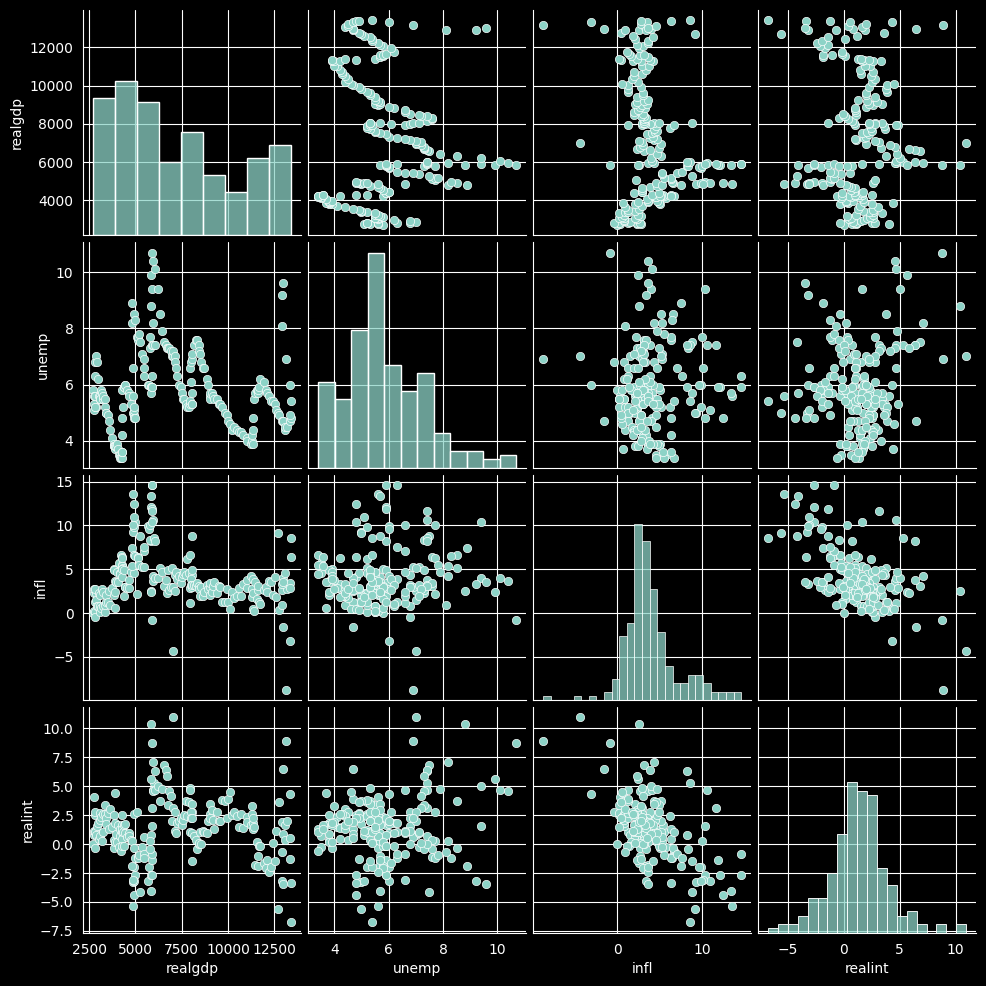

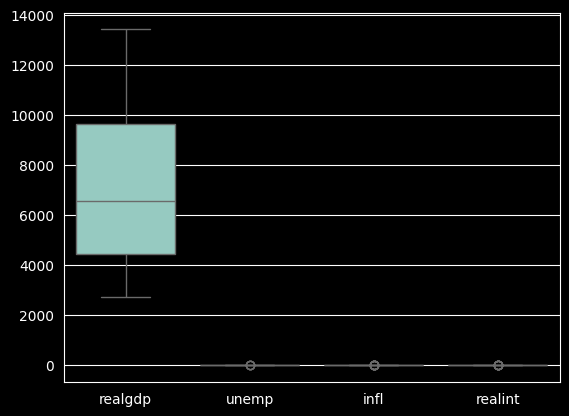

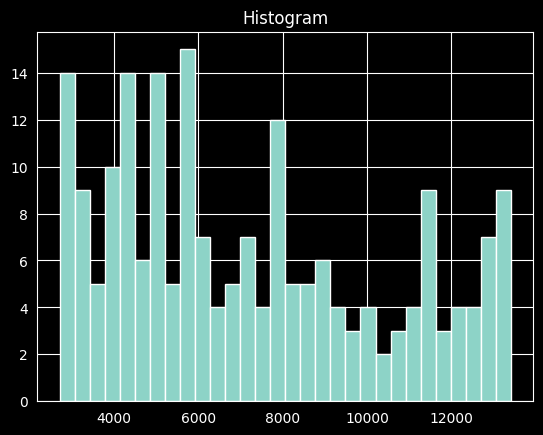

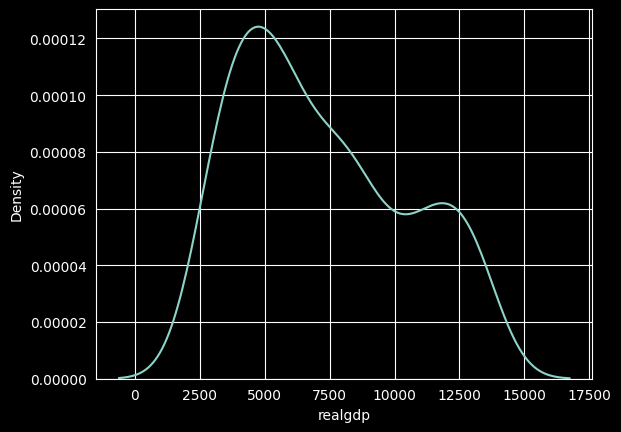

Baseline MAE: 6303.00
                            OLS Regression Results                            
Dep. Variable:                realgdp   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     3.882
Date:                Mon, 23 Mar 2026   Prob (F-statistic):             0.0103
Time:                        22:01:10   Log-Likelihood:                -1468.5
No. Observations:                 162   AIC:                             2945.
Df Residuals:                     158   BIC:                             2957.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4761.4788    724.7

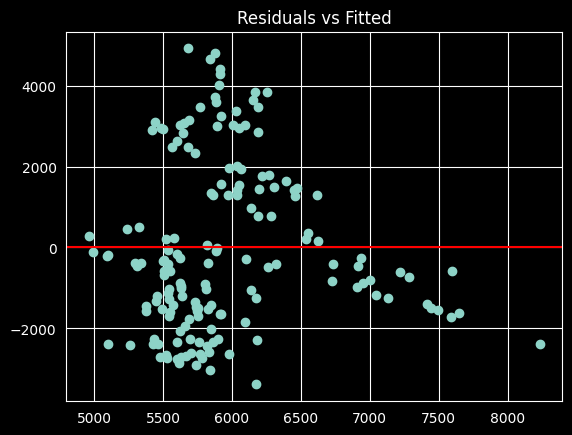

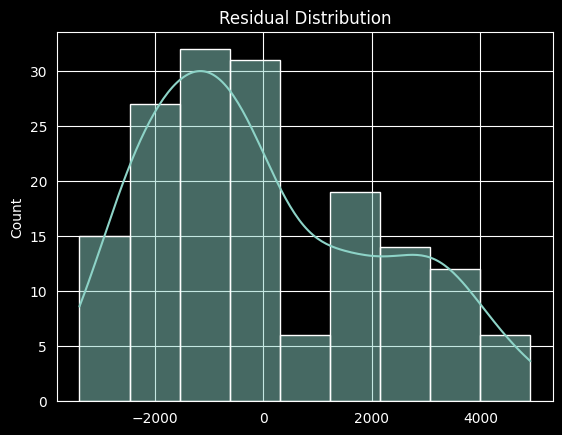

Train OLS: {'MAE': np.float64(1758.736774326811), 'MSE': np.float64(4376930.795988264), 'RMSE': np.float64(2092.1115639440127)}
Test OLS: {'MAE': np.float64(6858.020975176642), 'MSE': np.float64(48089566.19348708), 'RMSE': np.float64(6934.664100984783)}
Breusch-Pagan p-value (hetero): 0.0000
White p-value (hetero): 0.0000
Durbin-Watson: 0.03
ADF stationarity p-value: 0.9945


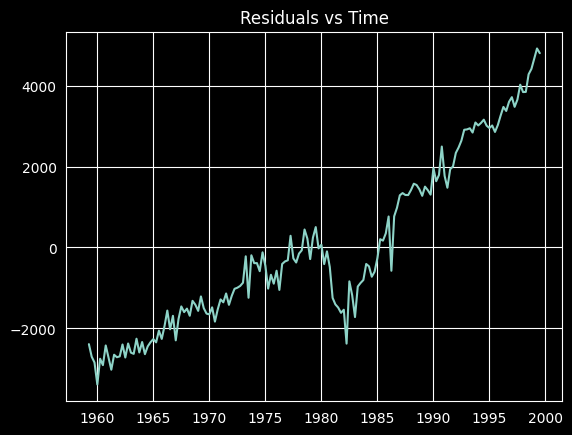

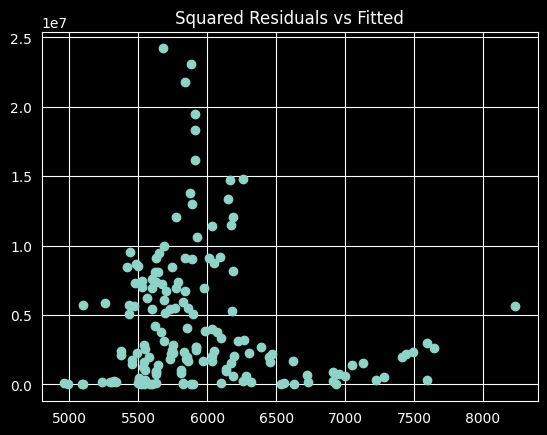

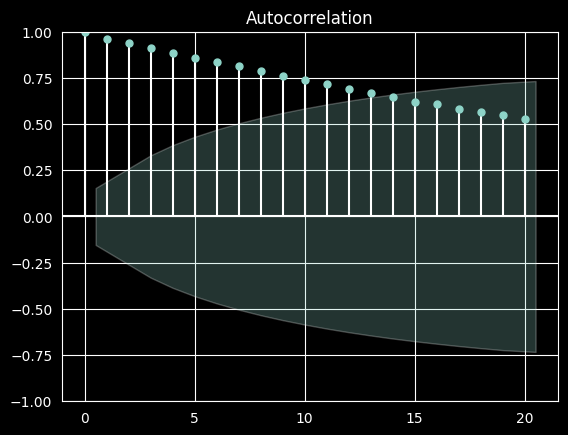

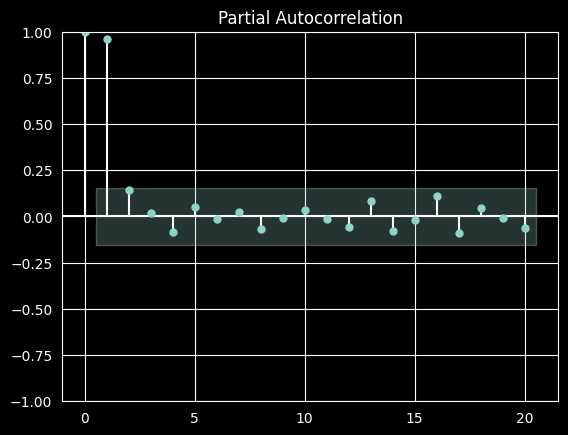


=== Newey-West HAC Summary ===
                            OLS Regression Results                            
Dep. Variable:                realgdp   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     3.019
Date:                Mon, 23 Mar 2026   Prob (F-statistic):             0.0316
Time:                        22:01:11   Log-Likelihood:                -1468.5
No. Observations:                 162   AIC:                             2945.
Df Residuals:                     158   BIC:                             2957.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4761.478

In [4]:
# Load time-series macro data (perfect for this workflow)
data = sm.datasets.macrodata.load_pandas().data
data.index = pd.date_range(start='1959Q1', periods=len(data), freq='Q')
y = data['realgdp']
X = data[['unemp', 'infl', 'realint']]
X = sm.add_constant(X)

print("=== 1. EDA: scatter, outliers, histogram, KDE ===")
sns.pairplot(data[['realgdp', 'unemp', 'infl', 'realint']])
plt.show()
sns.boxplot(data=data[['realgdp', 'unemp', 'infl', 'realint']])
plt.show()
data['realgdp'].hist(bins=30); plt.title('Histogram'); plt.show()
sns.kdeplot(data['realgdp']); plt.show()

# 2. Train/Test split (time-based) – last 20% as test
train_size = int(0.8 * len(data))
y_train, y_test = y[:train_size], y[train_size:]
X_train, X_test = X[:train_size], X[train_size:]

# 3. Baseline model (mean)
baseline_pred = y_train.mean()
baseline_mae = np.mean(np.abs(y_test - baseline_pred))
print(f"Baseline MAE: {baseline_mae:.2f}")

# 4. Run OLS (train data)
ols_model = OLS(y_train, X_train).fit()

# 5. Summary: coefficients, p-values, R²
print(ols_model.summary())

# 6. Residual analysis: scatter + distribution
resid = ols_model.resid
plt.scatter(ols_model.fittedvalues, resid); plt.axhline(0, color='r'); plt.title('Residuals vs Fitted'); plt.show()
sns.histplot(resid, kde=True); plt.title('Residual Distribution'); plt.show()

# 7. Metrics: MAE, MSE, RMSE (train + test)
train_pred = ols_model.predict(X_train)
test_pred = ols_model.predict(X_test)
def metrics(y_true, y_pred):
    return {'MAE': np.mean(np.abs(y_true - y_pred)),
            'MSE': np.mean((y_true - y_pred)**2),
            'RMSE': np.sqrt(np.mean((y_true - y_pred)**2))}

print("Train OLS:", metrics(y_train, train_pred))
print("Test OLS:", metrics(y_test, test_pred))

# 8. Diagnostics
bp_test = het_breuschpagan(resid, X_train)
white_test = het_white(resid, X_train)
print(f"Breusch-Pagan p-value (hetero): {bp_test[1]:.4f}")
print(f"White p-value (hetero): {white_test[1]:.4f}")
print(f"Durbin-Watson: {durbin_watson(resid):.2f}")
print(f"ADF stationarity p-value: {adfuller(resid)[1]:.4f}")

# 9. Visual diagnostics
plt.plot(y.index[:train_size], resid); plt.title('Residuals vs Time'); plt.show()
plt.scatter(ols_model.fittedvalues, resid**2); plt.title('Squared Residuals vs Fitted'); plt.show()
plot_acf(resid, lags=20); plt.show()
plot_pacf(resid, lags=20); plt.show()

# 10. Fixes
# Newey-West (HAC)
hac_results = ols_model.get_robustcov_results(cov_type='HAC', maxlags=4)
print("\n=== Newey-West HAC Summary ===")
print(hac_results.summary())

# WLS (weights = 1 / fitted²)
weights = 1 / (ols_model.fittedvalues ** 2)
wls_model = WLS(y_train, X_train, weights=weights).fit()
print("\n=== WLS Summary ===")
print(wls_model.summary())

# FGLS (simple 2-step)
resid2 = wls_model.resid
weights_fgls = 1 / np.abs(resid2)
fgls_model = WLS(y_train, X_train, weights=weights_fgls).fit()
print("\n=== FGLS Summary ===")
print(fgls_model.summary())

# 11. Re-evaluate (train + test)
print("Test WLS:", metrics(y_test, wls_model.predict(X_test)))
print("Test FGLS:", metrics(y_test, fgls_model.predict(X_test)))

# 12. Compare with baseline
print("All metrics vs Baseline – done above")

# 13. Economic interpretation
print("β_unemp (HAC):", hac_results.params[1], "→ 1% rise in unemployment → realgdp changes by $X billion")

# 14. Simplicity check → FGLS is still simple OLS-style, fully interpretable